# Do delivery times vary by country?

## Methodology

The three countries with the highest shipment volumes were selected to analyze delivery performance in greater detail.

In [1]:
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np

df = pd.read_csv(r'c:\Users\HP\Downloads\Supply_Chain_Shipment_Pricing_Data.csv')

cols_to_keep = [
    'country', 'vendor', 'shipment mode',
    'product group', 'sub classification',
    'po sent to vendor date', 'scheduled delivery date',
    'delivered to client date',
    'freight cost (usd)', 'line item insurance (usd)'
]
df = df[cols_to_keep]

list_to_date = ['scheduled delivery date', 'delivered to client date']

df = df.copy()                                          # To avoid SettingWithCopyWarning

for col in list_to_date:
    df[col] = pd.to_datetime(df[col], format='mixed')    # mixed format handles different date formats

### Data Aggregation
A pivot table was created to summarize shipment counts by shipment mode and delivery status.

In [2]:
df_delai = df.copy()

df_delai['delay'] = (
    df_delai['scheduled delivery date'] - df_delai['delivered to client date']
    ).dt.days

df_delai['shipment delivery'] = np.where(
    df_delai['delay'] < 0 , 'early',                         # if delay < 0 then 'early'
    np.where(                                                # if delay = 0 then 'on time'
        df_delai['delay'] == 0, 'on time',                   # else 'late'
    'late')
)


In [3]:
top3_country = df_delai['country'].value_counts().head(3).index         # top 3 country index

top3_country

Index(['South Africa', 'Nigeria', 'Côte d'Ivoire'], dtype='object', name='country')

In [4]:
df_top3 = df_delai[df_delai['country'].isin(top3_country)]               

df_top3

,country,vendor,shipment mode,product group,sub classification,po sent to vendor date,scheduled delivery date,delivered to client date,freight cost (usd),line item insurance (usd),delay,shipment delivery
0,Côte d'Ivoire,RANBAXY Fine Chemicals LTD.,Air,HRDT,HIV test,Date Not Captured,2006-06-02,2006-06-02,780.34,NaN,0,on time
2,Côte d'Ivoire,Abbott GmbH & Co. KG,Air,HRDT,HIV test,Date Not Captured,2006-08-27,2006-08-27,1653.78,NaN,0,on time
5,Nigeria,Aurobindo Pharma Limited,Air,ARV,Pediatric,Date Not Captured,2006-09-28,2006-09-28,5920.42,NaN,0,on time
8,Nigeria,Aurobindo Pharma Limited,Air,ARV,Adult,Date Not Captured,2006-12-07,2006-12-07,See ASN-93 (ID#:1281),NaN,0,on time
12,Nigeria,EY Laboratories,Air,HRDT,HIV test,Date Not Captured,2007-01-10,2007-01-10,Invoiced Separately,NaN,0,on time
...,...,...,...,...,...,...,...,...,...,...,...,...
10314,Nigeria,SCMS from RDC,Air Charter,ARV,Pediatric,N/A - From RDC,2015-06-30,2015-05-15,See DN-4274 (ID#:84472),38.27,46,late
10315,Nigeria,SCMS from RDC,Air Charter,ARV,Adult,N/A - From RDC,2015-06-30,2015-05-15,26180,1341.33,46,late
10316,Nigeria,SCMS from RDC,Air Charter,ARV,Adult,N/A - From RDC,2015-06-02,2015-05-15,3410,115.11,18,late
10317,Nigeria,SCMS from RDC,Air,ARV,Adult,N/A - From RDC,2015-06-30,2015-06-22,See DN-4282 (ID#:83919),24.69,8,late


### Data Aggregation

A pivot table was created to summarize delivery outcomes by country.

In [5]:
df_top3_pvt = df_top3.pivot_table(index = 'country',
                    columns = 'shipment delivery',
                    aggfunc = 'size').sort_values(by = 'on time', ascending = False)

df_top3_pvt['total'] = df_top3_pvt.sum(axis=1)

df_top3_pvt

shipment delivery,early,late,on time,total
country,,,,
South Africa,115,278,1013,1406
Côte d'Ivoire,134,349,600,1083
Nigeria,142,557,495,1194


In [6]:
for col in ['early', 'on time', 'late']:
    df_top3_pvt[col] = (df_top3_pvt[col] / df_top3_pvt['total']) * 100

df_top3_pvt.drop(columns = 'total', inplace = True)
df_top3_pvt

shipment delivery,early,late,on time
country,,,
South Africa,8.179232,19.772404,72.048364
Côte d'Ivoire,12.373038,32.225300,55.401662
Nigeria,11.892797,46.649916,41.457286


### Visualization

Pie charts were used to illustrate the percentage distribution of delivery outcomes for each of the top three countries.

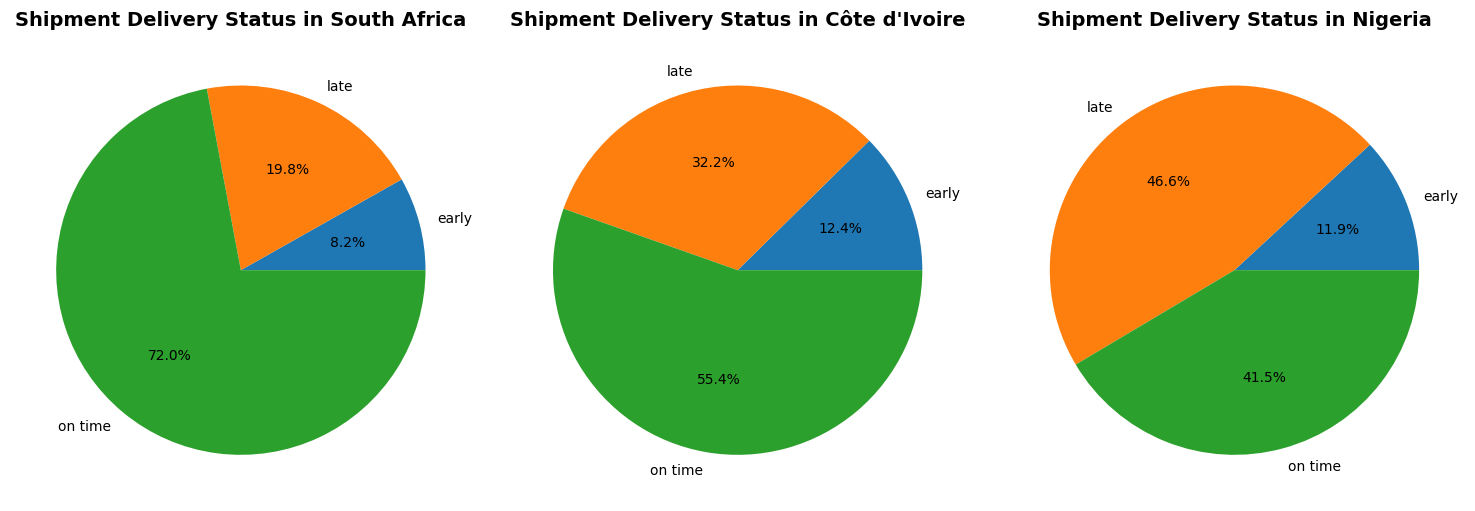

In [7]:
fig , ax = plt.subplots(1, 3, figsize = (15,5))

for i, country in enumerate(df_top3_pvt.index):
    df_top3_pvt.loc[country].plot(kind = 'pie',
                                  ax = ax[i],
                                  xlabel = '',
                                  ylabel = '',
                                  autopct = '%1.1f%%',
                                  )
    ax[i].set_title(f'Shipment Delivery Status in {country}', pad = 10, fontsize = 14, fontweight = 'bold')
    ax[i].legend().remove()
plt.tight_layout()
plt.show()
    
    

**Insight:**  
- Delivery reliability differs materially by country, with **South Africa performing strongly**, **Côte d’Ivoire at a moderate level**, and **Nigeria experiencing the highest share of late shipments**.  
- Higher delay rates, particularly in Nigeria, increase the risk of **service disruption, cost escalation, and customer dissatisfaction** in key markets.  
- **Prioritizing targeted operational improvements in Nigeria** and replicating best practices from South Africa could significantly improve overall regional performance.

---

# Which vendors are the most reliable?

### Methodology
The top seven vendors were identified based on the total number of shipments. Shipment delivery outcomes (early, late, on time) were then aggregated for each vendor using a pivot table.


### Data Aggregation

In [8]:
vd_i = df_delai['vendor'].value_counts().head(7).index         # Top 7 vendors

vd_i

Index(['SCMS from RDC', 'Orgenics, Ltd', 'S. BUYS WHOLESALER',
       'Aurobindo Pharma Limited', 'Trinity Biotech, Plc',
       'ABBVIE LOGISTICS (FORMERLY ABBOTT LOGISTICS BV)', 'PHARMACY DIRECT'],
      dtype='object', name='vendor')

In [9]:
df_vd_to7 = df_delai[df_delai['vendor'].isin(vd_i)]

df_vd_top7_pvt = df_vd_to7.pivot_table(index='vendor',
                                          columns = 'shipment delivery',
                                          aggfunc = 'size',
                                          fill_value = 0,
                        )


df_vd_top7_pvt

shipment delivery,early,late,on time
vendor,,,
ABBVIE LOGISTICS (FORMERLY ABBOTT LOGISTICS BV),4,2,341
Aurobindo Pharma Limited,94,22,552
"Orgenics, Ltd",98,64,592
PHARMACY DIRECT,0,0,326
S. BUYS WHOLESALER,11,240,464
SCMS from RDC,927,2409,2068
"Trinity Biotech, Plc",1,2,353


### Visualization

A horizontal bar chart was used to compare delivery outcomes across the top seven vendors.

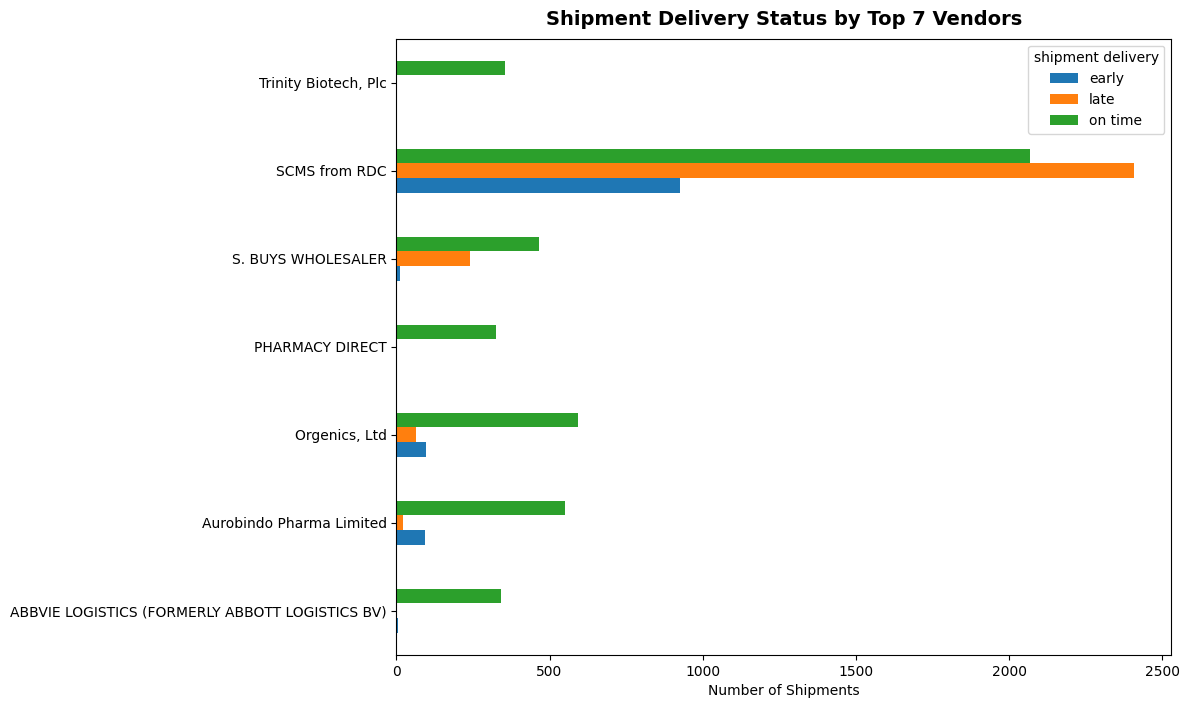

In [10]:
df_vd_top7_pvt.plot(kind = 'barh',
            figsize = (10,8),
            xlabel = '',
            ylabel = '',
            legend = True,
             )

plt.title('Shipment Delivery Status by Top 7 Vendors', pad = 10, fontsize = 14, fontweight = 'bold')
plt.xlabel('Number of Shipments')

plt.show()

**Insight:**  
- Shipment volume and delivery performance are **highly concentrated with SCMS from RDC**, which shows both the largest volume and a **notably high number of late deliveries**, creating outsized impact on overall performance.  
- Other vendors (e.g., **Organics, Ltd, Aurobindo Pharma Limited, S. BUYS WHOLESALER**) demonstrate **more stable on-time performance**, though at lower shipment volumes.  
- **Focusing performance improvement efforts on SCMS from RDC** would yield the greatest immediate benefit, while leveraging best practices from smaller, more reliable vendors could improve consistency across the vendor base.